---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 1"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 5. Метод еквівалентного генератора. Принцип накладення</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Метод еквівалентного генератора (теорема Тевенена)</li>
  <li>Розрахунок струму навантаження</li>
  <li>Формула переходу трикутник – зірка</li>
  <li>Принцип накладення (суперпозиції)</li>
  <li>Числовий приклад</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 5 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Метод еквівалентного генератора (теорема Тевенена)](#thevenin)
    * [Розрахунок струму навантаження](#thevenin-example)
    * [Формула переходу трикутник – зірка](#star-delta)
    * [🔬 Інтерактивно: характеристика навантаження еквівалентного генератора](#thevenin-interactive)
* [Принцип накладення (суперпозиції)](#superposition)
    * [Числовий приклад](#superposition-example)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

## Метод еквівалентного генератора (теорема Тевенена) <a class="anchor" id="thevenin"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Формулювати теорему Тевенена та Нортона
> - Знаходити напругу холостого ходу (ЕРС еквівалентного генератора)
> - Визначати внутрішній опір еквівалентної схеми
> - Розраховувати струм у навантаженні за допомогою еквівалентної схеми
> - Застосовувати перетворення зірка-трикутник

</div>

### Теорема Тевенена

> Будь-яке лінійне двополюсне коло може бути замінено **еквівалентним генератором напруги** з ЕРС $E_{ek}$ та внутрішнім опором $R_{ek}$, де:
> - $E_{ek} = U_{xx}$ — напруга холостого ходу на затискачах двополюсника
> - $R_{ek}$ — опір двополюсника з боку його затискачів при замкнених джерелах ЕРС



---
### Розрахунок струму навантаження <a class="anchor" id="thevenin-example"></a>

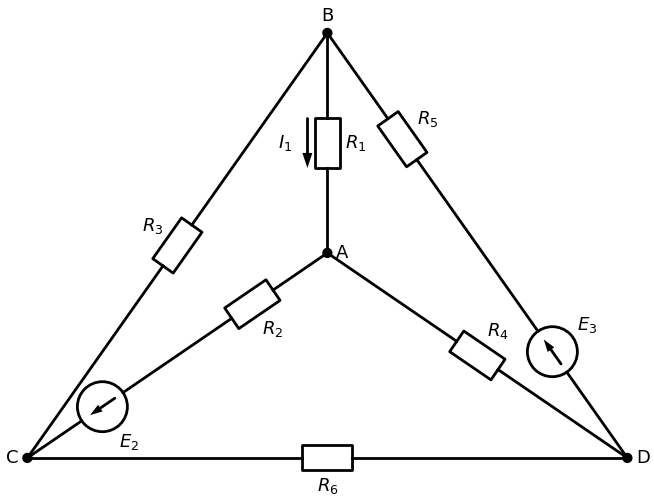

In [2]:
# Схема: складне коло з навантаженням R1 між вузлами A і B
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:
        import numpy as _np
        B, A, Cc, D = _np.array((0, 7)), _np.array((0, 2.6)), _np.array((-6, -1.5)), _np.array((6, -1.5))
        mid = lambda p, q: tuple((p + q)/2)
        R1 = d.add(elm.Resistor().endpoints(tuple(A), tuple(B)).label('$R_1$', loc='bottom'))
        d.add(elm.CurrentLabel(top=True, length=1.0, reverse=True).at(R1).label('$I_1$'))
        d.add(elm.Resistor().endpoints(tuple(B), tuple(Cc)).label('$R_3$'))
        d.add(elm.Resistor().endpoints(tuple(B), mid(B, D)).label('$R_5$', loc='top'))
        d.add(EMF().endpoints(tuple(D), mid(B, D)).label('$E_3$', loc='top'))
        d.add(elm.Resistor().endpoints(tuple(A), mid(A, Cc)).label('$R_2$', loc='bottom'))
        d.add(EMF().endpoints(mid(A, Cc), tuple(Cc)).label('$E_2$', loc='bottom'))
        d.add(elm.Resistor().endpoints(tuple(A), tuple(D)).label('$R_4$'))
        d.add(elm.Resistor().endpoints(tuple(Cc), tuple(D)).label('$R_6$', loc='bottom'))
        for p, name, loc in [(B, 'B', 'top'), (A, 'A', 'right'), (Cc, 'C', 'left'), (D, 'D', 'right')]:
            d.add(elm.Dot().at(tuple(p)).label(name, loc=loc))

Замінимо все коло відносно затискачів $A$ і $B$ еквівалентним генератором з ЕРС $E_{ek}$ та внутрішнім опором $R_{ek}$:

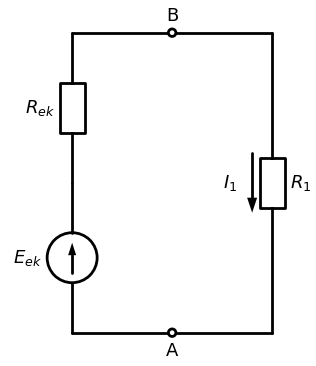

In [3]:
# Схема: еквівалентний генератор (E_ek, R_ek), навантажений опором R1
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:
        E = d.add(EMF().up().label('$E_{ek}$'))
        d.add(elm.Resistor().up().label('$R_{ek}$'))
        d.add(elm.Line().right(2))
        d.add(elm.Dot(open=True).label('B', loc='top'))
        d.add(elm.Line().right(2))
        R1 = d.add(elm.Resistor().down(6).label('$R_1$', loc='bottom'))
        d.add(elm.CurrentLabel(top=False, length=1.2).at(R1).label('$I_1$'))
        d.add(elm.Line().left(2))
        d.add(elm.Dot(open=True).label('A', loc='bottom'))
        d.add(elm.Line().left(2))

$$ I_{1} \cdot R_{ek} + I_{1} \cdot R_{1} = E_{ek} $$

$$ I_{1} \cdot ( R_{ek} + R_{1} ) = E_{ek} $$

$$ I_{1} = \cfrac{E_{ek}}{R_{ek} + R_{1}} $$



### Формула переходу трикутник – зірка <a class="anchor" id="star-delta"></a>

$$ R_{1} = \frac{R_{12}\cdot R_{31}}{R_{12} + R_{23} + R_{31}}$$

$$ R_{2} = \frac{R_{23}\cdot R_{12}}{R_{12} + R_{23} + R_{31}}$$

$$ R_{3} = \frac{R_{31}\cdot R_{23}}{R_{12} + R_{23} + R_{31}}$$

### Формула переходу зірка – трикутник

$$ R_{12} = R_{1} + R_{2} + \frac{R_{1} \cdot R_{2}}{R_{3} }$$

$$ R_{23} = R_{2} + R_{3} + \frac{R_{2} \cdot R_{3}}{R_{1} }$$

$$ R_{31} = R_{3} + R_{1} + \frac{R_{3} \cdot R_{1}}{R_{2} }$$

$$ I_{11} \cdot (R_3 + R_5 + R_6) - I_{22} \cdot R_6 = E_3 $$

$$ I_{22} \cdot (R_2 + R_4 + R_6) - I_{11} \cdot R_6 = -E_2 $$

---
### 🔬 Інтерактивно: характеристика навантаження еквівалентного генератора <a class="anchor" id="thevenin-interactive"></a>

<div style="background-color: #f5f3ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #7c3aed; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Змінюйте опір навантаження $R_L$ і стежте за струмом, напругою та потужністю в навантаженні. Максимум потужності досягається при $R_L = R_{ek}$ (узгоджене навантаження), але ККД при цьому лише 50 %.

</div>

In [4]:
# Інтерактивна теорема Тевенена: залежність струму навантаження від R_L
def thevenin_interactive(E_ek=48.0, R_ek=8.0, R_L_max=100.0):
    RL_vals = np.linspace(0.1, R_L_max, 300)
    I_L = E_ek / (R_ek + RL_vals)
    U_L = I_L * RL_vals
    P_L = I_L**2 * RL_vals
    P_L_max_idx = np.argmax(P_L)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(RL_vals, I_L, color='#2196F3')
    axes[0].axvline(R_ek, color='red', linestyle='--', label=f'R_L = R_ek = {R_ek} Ом')
    axes[0].set_xlabel('R_L, Ом'); axes[0].set_ylabel('I_L, А')
    axes[0].set_title('Струм навантаження I_L(R_L)')
    axes[0].legend()

    axes[1].plot(RL_vals, U_L, color='#4CAF50')
    axes[1].axvline(R_ek, color='red', linestyle='--')
    axes[1].set_xlabel('R_L, Ом'); axes[1].set_ylabel('U_L, В')
    axes[1].set_title('Напруга навантаження U_L(R_L)')

    axes[2].plot(RL_vals, P_L, color='#FF9800')
    axes[2].axvline(RL_vals[P_L_max_idx], color='red', linestyle='--',
                    label=f'P_max при R_L={RL_vals[P_L_max_idx]:.1f} Ом')
    axes[2].set_xlabel('R_L, Ом'); axes[2].set_ylabel('P_L, Вт')
    axes[2].set_title('Потужність P_L(R_L)')
    axes[2].legend()

    plt.suptitle(f'Схема Тевенена: E_ek={E_ek} В, R_ek={R_ek} Ом | '
                 f'P_max={P_L.max():.2f} Вт при R_L=R_ek={R_ek} Ом', fontsize=11)
    plt.tight_layout(); plt.show()
    print(f'P_max = E_ek^2 / (4*R_ek) = {E_ek**2/(4*R_ek):.4f} Вт')
    print(f'Умова максимальної передачі потужності: R_L = R_ek = {R_ek} Ом')

interact(thevenin_interactive,
         E_ek=widgets.FloatSlider(min=5, max=200, step=5, value=48, description='E_ek (В)'),
         R_ek=widgets.FloatSlider(min=1, max=100, step=1, value=8, description='R_ek (Ом)'),
         R_L_max=widgets.FloatSlider(min=10, max=500, step=10, value=100, description='R_L max (Ом)'))

interactive(children=(FloatSlider(value=48.0, description='E_ek (В)', max=200.0, min=5.0, step=5.0), FloatSlid…

<function __main__.thevenin_interactive(E_ek=48.0, R_ek=8.0, R_L_max=100.0)>

---
### ⚡ Практичне застосування: Теорема Тевенена

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Умова максимальної передачі потужності (теорема про максимальну потужність):**

$$P_{L,\max} = \frac{E_{ek}^2}{4 R_{ek}}, \quad \text{при } R_L = R_{ek}$$

**Реальні приклади узгодження опорів:**

| Пристрій | R_ek джерела | R_L навантаження | Мета |
|----------|------------|-----------------|------|
| **Радіопередавач — антена** | 50 Ом | 50 Ом | Максимальна потужність в антені |
| **Мікрофон — передпідсилювач** | 200 Ом | 10 кОм | Мінімальні шуми (не max P) |
| **Підсилювач потужності — АС** | 4–8 Ом | 4–8 Ом | Максимальна акустична потужність |
| **Генератор ВЧ — вимірювальний прилад** | 50 Ом | 50 Ом | Узгоджений режим |

> **Важливо:** В підсилювальних каскадах метою часто є **не** максимальна потужність, а
> мінімальний коефіцієнт шуму — тому $R_L \neq R_{ek}$.

</div>

---
### ✅ Питання для самоперевірки: Теорема Тевенена

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Як визначити $E_{ek}$ і $R_{ek}$?</summary>

> **Відповідь:**
> - $E_{ek}$ — напруга холостого ходу на затискачах: $E_{ek} = U_{ab}\big|_{R_L=\infty}$.
> - $R_{ek}$ — опір двополюсника при замкнених (занулених) незалежних джерелах: $R_{ek} = R_{ab}\big|_{E_k=0,\ J_k=0}$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> У чому різниця між теоремами Тевенена і Нортона?</summary>

> **Відповідь:** Теорема Тевенена: еквівалентне джерело напруги $E_{ek}$ послідовно з $R_{ek}$. Теорема Нортона: еквівалентне джерело струму $J_{ek} = E_{ek}/R_{ek}$ паралельно з $R_{ek}$. Обидві теореми дають однаковий режим навантаження.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> При якій умові навантаження отримує максимальну потужність?</summary>

> **Відповідь:** $R_L = R_{ek}$. Тоді $P_{max} = E_{ek}^2 / (4 R_{ek})$. ККД при цьому становить 50% (половина потужності розсіюється на $R_{ek}$).

</details>

---
### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Теорему про еквівалентний генератор незалежно відкрили **Леон Тевенен** (1883, французький інженер-телеграфіст) та, у формі джерела струму, **Едвард Нортон** (1926, інженер Bell Labs). Обидва подання рівносильні: $J_{ek} = E_{ek}/R_{ek}$. Саме теорема Тевенена лежить в основі поняття **вихідного опору джерела** та **узгодження імпедансів** — ключової ідеї при проєктуванні НВЧ-трактів і антенних фідерів.


</div>


---
### 📝 Задачі для самостійного розв'язання: Метод еквівалентного генератора


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Дільник напруги $E = 30$ В, $R_1 = 10$ Ом, $R_2 = 20$ Ом; навантаження $R_н$ підключається паралельно $R_2$. Знайдіть параметри еквівалентного генератора, струм при $R_н = 10$ Ом та максимальну потужність, яку можна отримати в навантаженні.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $E_{ek} = U_{xx} = 30\cdot\dfrac{20}{30} = 20$ В; $R_{ek} = R_1\|R_2 \approx 6{,}67$ Ом.
> $I_н = \dfrac{20}{6{,}67 + 10} = 1{,}2$ А. $P_{max} = \dfrac{E_{ek}^2}{4R_{ek}} = 15$ Вт при $R_н = R_{ek}$.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Перетворіть трикутник $R_{12} = 10$ Ом, $R_{23} = 20$ Ом, $R_{31} = 30$ Ом на еквівалентну зірку.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\Sigma R = 60$ Ом. $R_1 = \dfrac{R_{12}R_{31}}{\Sigma R} = 5$ Ом, $R_2 = \dfrac{R_{12}R_{23}}{\Sigma R} \approx 3{,}33$ Ом, $R_3 = \dfrac{R_{23}R_{31}}{\Sigma R} = 10$ Ом.

</details>

---

## Принцип накладення (суперпозиції) <a class="anchor" id="superposition"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Формулювати принцип накладення для лінійних кіл
> - Розраховувати парціальні струми від кожного джерела окремо
> - Визначати результуючі струми як алгебраїчну суму парціальних

</div>

### 📐 Формулювання принципу

<div style="background-color: #f8fafc; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #475569; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

У лінійному електричному колі з декількома джерелами **відгук** (струм або напруга) в будь-якій гілці дорівнює **алгебраїчній сумі** відгуків, спричинених кожним джерелом окремо, при умові, що решта джерел замінені їх внутрішніми опорами:
- Джерело **ЕРС** замінюється **коротким замиканням** (його внутрішнім опором)
- Джерело **струму** замінюється **розривом** (нескінченним опором)

$$I_k = I_k^{(1)} + I_k^{(2)} + \ldots + I_k^{(n)}$$

</div>



---
### Числовий приклад <a class="anchor" id="superposition-example"></a>

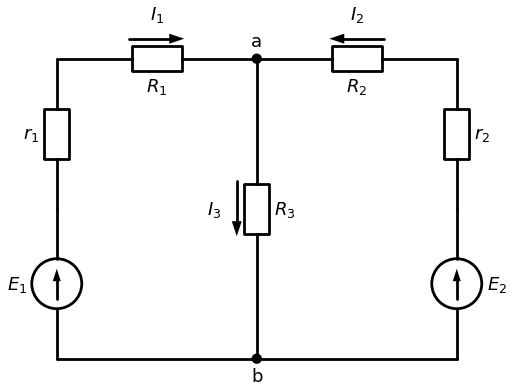

In [5]:
# Схема: коло з двома джерелами ЕРС для принципу накладення
if SCHEMDRAW_AVAILABLE:
    def superposition_circuit(with_E1=True, with_E2=True, currents=('I_1', 'I_2', 'I_3'), dirs=(1, -1)):
        """Коло для принципу накладення. dirs — напрямки струмів у R1 та R2 (+1 — праворуч)."""
        with schemdraw.Drawing(fontsize=13, unit=3) as d:
            d.add(EMF().up().label('$E_1$') if with_E1 else elm.Line().up())
            d.add(elm.Resistor().up().label('$r_1$'))
            R1 = d.add(elm.Resistor().right(4).label('$R_1$', loc='bottom'))
            d.add(elm.CurrentLabel(top=True, length=1.1, reverse=dirs[0] < 0).at(R1).label(f'${currents[0]}$'))
            a = d.add(elm.Dot().label('a', loc='top'))
            R2 = d.add(elm.Resistor().right(4).label('$R_2$', loc='bottom'))
            d.add(elm.CurrentLabel(top=True, length=1.1, reverse=dirs[1] < 0).at(R2).label(f'${currents[1]}$'))
            d.add(elm.Resistor().down().label('$r_2$', loc='bottom'))
            d.add(EMF().down().reverse().label('$E_2$', loc='bottom') if with_E2 else elm.Line().down())
            d.add(elm.Line().left(4))
            d.add(elm.Dot().label('b', loc='bottom'))
            d.add(elm.Line().left(4))
            R3 = d.add(elm.Resistor().at(a.center).down(6).label('$R_3$', loc='bottom'))
            d.add(elm.CurrentLabel(top=False, length=1.1).at(R3).label(f'${currents[2]}$'))

    superposition_circuit()

### Перша схема

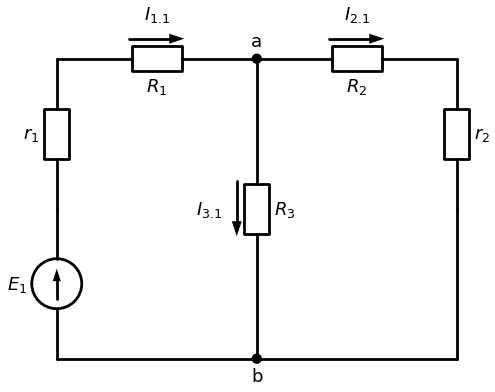

In [6]:
# Схема: перша часткова схема — діє лише E1 (E2 замкнено накоротко, r2 залишається)
if SCHEMDRAW_AVAILABLE:
    superposition_circuit(with_E2=False, currents=('I_{1.1}', 'I_{2.1}', 'I_{3.1}'), dirs=(1, 1))

Розраховуємо опір другої гілки

$$ R_{22} = R_{2} + r_{2} $$

Розраховуємо опір між вузлами ab

$$ R_{ab1} = \cfrac{R_{3} \cdot R_{22}}{R_{3} + R_{22}} $$

Розраховуємо загальний еквівалентний опір

$$ R_{e1} = R_{ab} + R_{1} + r_{1}$$

Розраховуємо струм в першій гілці

$$ I_{1.1} = \cfrac{E_{1}}{R_{e1}} $$

Знаходимо напругу між вузлами

$$ V_{ab1} = I_{1.1} \cdot R_{ab1}$$

Знаходимо струм в третій гілці

$$ I_{3.1} = \cfrac{V_{ab}}{R_{3}}$$

Знаходимо струм в другій гілці

$$ I_{2.1} = \cfrac{V_{ab1}}{R_{2} + r_{2}}$$

$$ I_{2.1} = I_{1.1} - I_{3.1}$$



### Друга схема

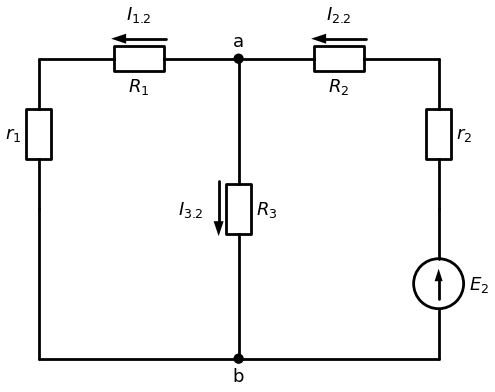

In [7]:
# Схема: друга часткова схема — діє лише E2 (E1 замкнено накоротко, r1 залишається)
if SCHEMDRAW_AVAILABLE:
    superposition_circuit(with_E1=False, currents=('I_{1.2}', 'I_{2.2}', 'I_{3.2}'), dirs=(-1, -1))

Розраховуємо опір першої гілки

$$ R_{11} = R_{1} + r_{1} $$

Розраховуємо опір між вузлами ab

$$ R_{ab2} = \cfrac{R_{3} \cdot R_{11}}{R_{3} + R_{11}} $$

Розраховуємо загальний еквівалентний опір

$$ R_{e2} = R_{ab} + R_{2} + r_{2}$$

Розраховуємо струм в першій гілці

$$ I_{2.2} = \cfrac{E_{2}}{R_{e2}} $$

Знаходимо напругу між вузлами

$$ V_{ab2} = I_{2.2} \cdot R_{ab2}$$

Знаходимо струм в третій гілці

$$ I_{3.2} = \cfrac{V_{ab}}{R_{3}}$$

Знаходимо струм в першій гілці

$$ I_{1.2} = \cfrac{V_{ab2}}{R_{1} + r_{1}}$$

$$ I_{1.2} = I_{2.2} - I_{3.2}$$



Запишемо струми в гілках

> $$ I_{1} = I_{1.1} - I_{1.2}$$
> 
> $$ I_{2} = I_{2.2} - I_{2.1}$$
>
> $$ I_{3} = I_{3.1} + I_{3.2}$$

**Числовий приклад.** Задамо $E_1 = 60$ В, $E_2 = 30$ В, $R_1 = R_3 = 10$ Ом, $R_2 = 40$ Ом і знайдемо в SymPy контурні струми $I_{11}$ та $I_{22}$ у символьному вигляді.

In [8]:
# Крок 1: параметри кола
E1_s = 60;
E2_s = 30;

R1_s = 10;
R2_s = 40;
R3_s = 10;

E1 = smp.symbols('E1')
E2 = smp.symbols('E2')
R1 = smp.symbols('R1')
R2 = smp.symbols('R2')
R3 = smp.symbols('R3')

I11 = smp.symbols('I11')
I22 = smp.symbols('I22')

# Крок 2: система рівнянь
eq = [I11 * (R1 + R3) - I22 * R3 - E1,  
      I22 * (R3 + R2) - I11 * R3 + E2]

# Крок 3: розв'язуємо систему рівнянь
sol = smp.solve(eq, [I11, I22])
sol

{I11: (E1*R2 + E1*R3 - E2*R3)/(R1*R2 + R1*R3 + R2*R3),
 I22: (E1*R3 - E2*R1 - E2*R3)/(R1*R2 + R1*R3 + R2*R3)}

Поставимо зворотну задачу: яку ЕРС $E_1$ треба задати, щоб струм $I_{11}$ дорівнював 5 А? Запишемо рівняння $I_{11}(E_1) - 5 = 0$:

In [9]:
eq2 = (E1*R2 + E1*R3 - E2*R3)/(R1*R2 + R1*R3 + R2*R3)-5

Розв'яжемо це рівняння відносно $E_1$:

In [10]:
sol2 = smp.solve(eq2, [E1])

Символьний вираз для $E_1$:

In [11]:
sol2

[(E2*R3 + 5*R1*R2 + 5*R1*R3 + 5*R2*R3)/(R2 + R3)]

Підставимо числові значення $E_2$, $R_1$, $R_2$, $R_3$ і отримаємо потрібну ЕРС $E_1$ у вольтах:

In [12]:
print(sol2[0].subs(E2, E2_s).subs(R1, R1_s).subs(R2, R2_s).subs(R3, R3_s))


96


---
### ⚡ Практичне застосування: Принцип суперпозиції

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Суперпозиція в радіотехніці:**

- **Лінійне підсумовування сигналів на вході підсилювача:** Якщо підсилювач лінійний, вихідний сигнал — сума підсилених вхідних сигналів.
- **Завади (шум + корисний сигнал):** Кожне джерело діє незалежно; аналіз SNR (відношення сигнал/шум) використовує принцип суперпозиції.
- **Гармонічний аналіз (Фур'є + суперпозиція):** Довільний сигнал розкладається на гармоніки; реакція лінійного кола = сума реакцій на кожну гармоніку.
- **Обмеження:** Принцип **не** застосовується до нелінійних кіл (транзисторний підсилювач у режимі насичення, діодний детектор).

> **Критерій лінійності:** Схема лінійна, якщо виконується суперпозиція і однорідність: $f(ax_1 + bx_2) = af(x_1) + bf(x_2)$.

</div>

---
### ✅ Питання для самоперевірки: Принцип суперпозиції

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому принцип суперпозиції не застосовується до нелінійних схем?</summary>

> **Відповідь:** У нелінійних схемах вихідний сигнал не є лінійною функцією вхідних сигналів. Наприклад, у діодній схемі $I = I_s(e^{U/U_T}-1)$: $I(U_1 + U_2) \neq I(U_1) + I(U_2)$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Як вимкнути джерело напруги і джерело струму при застосуванні суперпозиції?</summary>

> **Відповідь:** Джерело **напруги** замінюється коротким замиканням ($E = 0 \Rightarrow U = 0$). Джерело **струму** замінюється розривом ($J = 0 \Rightarrow I = 0$).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чи можна застосувати суперпозицію до потужності?</summary>

> **Відповідь:** Ні. Потужність є квадратичною функцією струму/напруги. Загальна потужність $P = (I_1 + I_2)^2 R = P_1 + P_2 + 2I_1 I_2 R \neq P_1 + P_2$. Суперпозиція — лише для напруг та струмів.

</details>

---
### 📝 Задачі для самостійного розв'язання: Принцип накладення


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Розв'яжіть задачу 1 з розділу «Закони Кірхгофа» ($E_1 = 10$ В, $R_1 = 2$ Ом; $E_2 = 5$ В, $R_2 = 1$ Ом; $R_3 = 4$ Ом) методом накладення. Знайдіть струм $I_3$.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Лише $E_1$: $R_2\|R_3 = 0{,}8$ Ом, $I_1' = 10/2{,}8 \approx 3{,}571$ А, $I_3' = 3{,}571\cdot0{,}8/4 \approx 0{,}714$ А.
> Лише $E_2$: $R_1\|R_3 \approx 1{,}333$ Ом, $I_2'' = 5/2{,}333 \approx 2{,}143$ А, $I_3'' \approx 0{,}714$ А.
> $I_3 = I_3' + I_3'' \approx 1{,}429$ А — збігається з розв'язком за законами Кірхгофа ✔.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Для попередньої задачі порівняйте потужність у $R_3$, обчислену за повним струмом, із сумою «парціальних» потужностей. Чому вони різні?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $P = I_3^2R_3 \approx 8{,}16$ Вт, а $(I_3'^2 + I_3''^2)R_3 \approx 4{,}08$ Вт. Потужність — **квадратична** функція струму, тому принцип накладення для неї не виконується.

</details>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 4. Метод контурних струмів](Тема_04_Метод_контурних_струмів.ipynb) &nbsp;|&nbsp; [Тема 6. Символічний метод розрахунку кіл синусоїдного струму](Тема_06_Символічний_метод.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
